# Tufa Labs ARC3 submission

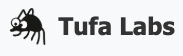

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
os.environ["LORA_BOOT_ONLY"] = "1"  # serve canary: measure the LoRA serve path, SKIP the game window
print(
    "LORA-SERVE-CANARY mode=boot-only "
    "brain=driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot (UNCHANGED, the scored brain) "
    "wheels=driessmit1/arc3-vllm-h100-wheelhouse-v3 (UNCHANGED, vLLM 0.19.0) "
    "delta=--enable-lora + two RANDOM r16 adapters (noop B=0, probe B~1e-3) AND NOTHING ELSE "
    "measures=adapter load + differential apply + tool-call + MM + LoRA throughput tax; "
    "NO training tokens were spent to produce these adapters",
    flush=True,
)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
# LORA-SERVE-CANARY: the scored triple is UNCHANGED; the probe adapters are the only
# addition (two 40 MB directories, built locally, never trained).
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot", "canivel/arc3-lora-probe-adapters"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# --- LORA-SERVE-CANARY BEGIN serve-config rewrite (loud-fail; no adapter-free fallback) ---
# A vanilla fallback would serve the base with no adapter and report it as a LoRA run.
# That is the silent null this canary exists to prevent, so ANY miss raises.
LORA_SETUP_REWRITES = [('import json\nimport os\n', 'import base64\nimport hashlib\nimport json\nimport os\n'), ('\n\ndef run_vllm_api_smoke_test() -> None:', '\n\n# ===================== LORA-SERVE-CANARY =====================\n_LORA_ADAPTERS = {\'arc3-noop\': None, \'arc3-probe\': None}\n\n\ndef _lora_find_adapters() -> None:\n    root = resolve_kaggle_dataset_path(\'canivel\', \'arc3-lora-probe-adapters\')\n    if not root.exists():\n        raise FileNotFoundError(\'LORA-CANARY FATAL: adapter dataset not mounted at \' + str(root))\n    for name, sub in ((\'arc3-noop\', \'lora-noop\'), (\'arc3-probe\', \'lora-probe\')):\n        hits = [p.parent for p in root.rglob(\'adapter_config.json\') if p.parent.name == sub]\n        if not hits:\n            listing = sorted(str(p.relative_to(root)) for p in root.rglob(\'*\'))[:40]\n            raise FileNotFoundError(\n                \'LORA-CANARY FATAL: no \' + sub + \'/adapter_config.json under \' + str(root)\n                + \' contents=\' + repr(listing))\n        path = hits[0]\n        weights = path / \'adapter_model.safetensors\'\n        raw = weights.read_bytes()\n        digest = hashlib.sha256(raw).hexdigest()[:16]\n        want = {"lora-noop": "d777d4c7a7ebec85", "lora-probe": "d7d6918d01ae67f6"}[sub]\n        if digest != want:\n            raise RuntimeError(\'LORA-CANARY FATAL: \' + sub + \' sha \' + digest + \' != \' + want\n                               + \' (the dataset push did not ship what we built)\')\n        cfg = json.loads((path / \'adapter_config.json\').read_text())\n        if int(cfg.get(\'r\', 0)) != 16:\n            raise RuntimeError(\'LORA-CANARY FATAL: \' + sub + \' rank \' + repr(cfg.get(\'r\')))\n        _LORA_ADAPTERS[name] = path\n        print(\'LORA-CANARY adapter %s path=%s bytes=%d sha=%s r=%d rslora=%s\'\n              % (name, path, len(raw), digest, cfg[\'r\'], cfg.get(\'use_rslora\')), flush=True)\n\n\ndef _lora_install_guard() -> None:\n    """Wire Tufa\'s own, never-called `inference/tools/vllm_runtime_lora_guard.py` into the\n    vLLM SERVER process. It turns "vLLM would silently ignore this LoRA module" warnings into\n    hard errors -- exactly the failure class this canary is here to detect. The server is a\n    subprocess, so the hook is delivered by a `sitecustomize.py` on its PYTHONPATH that defers\n    the patch until `vllm.lora.worker_manager` is actually imported. Best-effort and REPORTED:\n    the primary evidence is the noop/probe differential, which detects a silent ignore\n    behaviourally. A guard that fails to install must not cost a GPU-hour."""\n    guard_src = None\n    for base in _source_path_entries(BUNDLE_DIR):\n        candidate = Path(base) / \'inference\' / \'tools\' / \'vllm_runtime_lora_guard.py\'\n        if candidate.is_file():\n            guard_src = candidate\n            break\n    if guard_src is None:\n        print(\'LORA-CANARY guard=NOT-FOUND (vllm_runtime_lora_guard.py absent from the bundle)\', flush=True)\n        return\n    SITE_PACKAGES.mkdir(parents=True, exist_ok=True)\n    (SITE_PACKAGES / \'_arc3_lora_guard.py\').write_text(guard_src.read_text(), encoding=\'utf-8\')\n    (SITE_PACKAGES / \'sitecustomize.py\').write_text(\n        \'import importlib.abc, importlib.machinery, sys\\n\'\n        \'class _H(importlib.abc.MetaPathFinder):\\n\'\n        \'    def find_module(self, *a, **k):\\n\'\n        \'        return None\\n\'\n        \'    def find_spec(self, name, path=None, target=None):\\n\'\n        \'        if name != "vllm.lora.worker_manager":\\n\'\n        \'            return None\\n\'\n        \'        sys.meta_path.remove(self)\\n\'\n        \'        spec = importlib.machinery.PathFinder.find_spec(name, path, target)\\n\'\n        \'        if spec is None:\\n\'\n        \'            return None\\n\'\n        \'        orig = spec.loader.exec_module\\n\'\n        \'        def exec_module(module, _orig=orig):\\n\'\n        \'            _orig(module)\\n\'\n        \'            try:\\n\'\n        \'                import _arc3_lora_guard\\n\'\n        \'                _arc3_lora_guard.install_runtime_lora_warning_guard()\\n\'\n        \'                print("LORA-CANARY guard=INSTALLED (in vLLM server process)", flush=True)\\n\'\n        \'            except Exception as exc:\\n\'\n        \'                print("LORA-CANARY guard=FAILED " + repr(exc)[:200], flush=True)\\n\'\n        \'        spec.loader.exec_module = exec_module\\n\'\n        \'        return spec\\n\'\n        \'sys.meta_path.insert(0, _H())\\n\',\n        encoding=\'utf-8\')\n    print(\'LORA-CANARY guard=STAGED at \' + str(SITE_PACKAGES / \'sitecustomize.py\'), flush=True)\n\n\ndef _lora_png_b64(size: int = 64) -> str:\n    # Dependency-free solid-colour PNG for the MM probe.\n    import struct\n    import zlib\n    raw = (b\'\\x00\' + b\'\\xc8\\x32\\x32\' * size) * size\n\n    def _chunk(tag, data):\n        return (struct.pack(\'>I\', len(data)) + tag + data\n                + struct.pack(\'>I\', zlib.crc32(tag + data) & 0xFFFFFFFF))\n\n    ihdr = struct.pack(\'>IIBBBBB\', size, size, 8, 2, 0, 0, 0)\n    png = (b\'\\x89PNG\\r\\n\\x1a\\n\' + _chunk(b\'IHDR\', ihdr)\n           + _chunk(b\'IDAT\', zlib.compress(raw)) + _chunk(b\'IEND\', b\'\'))\n    return base64.b64encode(png).decode(\'ascii\')\n\n\n_LORA_DIFF_PROMPT = (\'You are analysing a 64x64 ARC grid. In exactly one sentence, describe a \'\n                     \'strategy for finding the shortest action sequence that clears a level.\')\n\n\ndef _lora_greedy(model_name: str, n: int = 48) -> dict:\n    payload = {\'model\': model_name,\n               \'messages\': [{\'role\': \'user\', \'content\': _LORA_DIFF_PROMPT}],\n               \'temperature\': 0.0, \'top_p\': 1.0, \'seed\': 20260813,\n               \'max_tokens\': n, \'logprobs\': True, \'top_logprobs\': 1,\n               \'chat_template_kwargs\': {\'enable_thinking\': False}}\n    response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=600)\n    choice = response[\'choices\'][0]\n    content = choice[\'message\'].get(\'content\') or \'\'\n    lp = choice.get(\'logprobs\') or {}\n    toks = [t.get(\'token\') for t in (lp.get(\'content\') or [])]\n    vals = [t.get(\'logprob\') for t in (lp.get(\'content\') or [])]\n    return {\'text\': content, \'tokens\': toks, \'logprobs\': vals}\n\n\ndef _lora_serve_asserts() -> None:\n    # FAIL-LOUD. A dead canary is a retry; a silently-wrong serve path is a poisoned verdict.\n    models = request_json(VLLM_BASE_URL + \'/models\', timeout=60)\n    ids = sorted(m.get(\'id\', \'\') for m in models.get(\'data\', []))\n    want = sorted([SERVED_MODEL_NAME, \'arc3-noop\', \'arc3-probe\'])\n    if ids != want:\n        raise RuntimeError(\'LORA-CANARY FATAL: /v1/models = \' + repr(ids) + \' != \' + repr(want)\n                           + \' -- vLLM did not register both adapters\')\n    print(\'LORA-CANARY models_endpoint=OK ids=\' + repr(ids), flush=True)\n\n    # (1) THE DIFFERENTIAL. This is the whole canary.\n    base = _lora_greedy(SERVED_MODEL_NAME)\n    noop = _lora_greedy(\'arc3-noop\')\n    probe = _lora_greedy(\'arc3-probe\')\n    noop_same = noop[\'tokens\'] == base[\'tokens\']\n    probe_diff = probe[\'tokens\'] != base[\'tokens\']\n    first_div = next((i for i, (a, b) in enumerate(zip(base[\'tokens\'], probe[\'tokens\'])) if a != b),\n                     None)\n    print(\'LORA-CANARY differential noop_identical_to_base=%s probe_differs_from_base=%s \'\n          \'first_divergent_token_index=%s\' % (noop_same, probe_diff, first_div), flush=True)\n    print(\'LORA-CANARY base_text=\' + repr(base[\'text\'][:160]), flush=True)\n    print(\'LORA-CANARY probe_text=\' + repr(probe[\'text\'][:160]), flush=True)\n    if not noop_same:\n        raise RuntimeError(\'LORA-CANARY FATAL: a ZERO-delta adapter changed the output. The LoRA \'\n                           \'path is numerically unsound, not merely inactive. base=%r noop=%r\'\n                           % (base[\'tokens\'][:12], noop[\'tokens\'][:12]))\n    if not probe_diff:\n        raise RuntimeError(\'LORA-CANARY FATAL: a NON-ZERO adapter did not change the output. The \'\n                           \'adapter is being SILENTLY IGNORED -- this is the exact failure class \'\n                           \'Tufa built vllm_runtime_lora_guard for, and it would have read as \'\n                           \'"LoRA did not help" after a full training run.\')\n    print(\'LORA-CANARY differential=PASS (adapter is loaded AND applied)\', flush=True)\n\n    # (2) tool-call round-trip through the harness\'s own parser, ADDRESSED TO THE ADAPTER.\n    tools = [{\'type\': \'function\', \'function\': {\n        \'name\': \'python\',\n        \'description\': \'Run python against the live frame.\',\n        \'parameters\': {\'type\': \'object\',\n                       \'properties\': {\'code\': {\'type\': \'string\'}},\n                       \'required\': [\'code\']}}}]\n    payload = {\'model\': \'arc3-probe\',\n               \'messages\': [{\'role\': \'user\',\n                             \'content\': "Call the python tool with code exactly: action([\'UP\'])"}],\n               \'tools\': tools,\n               \'tool_choice\': {\'type\': \'function\', \'function\': {\'name\': \'python\'}},\n               \'temperature\': 0.0, \'max_tokens\': 512}\n    response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=600)\n    calls = response[\'choices\'][0][\'message\'].get(\'tool_calls\') or []\n    if not calls or calls[0].get(\'function\', {}).get(\'name\') != \'python\':\n        raise RuntimeError(\'LORA-CANARY FATAL: tool-call round-trip FAILED under qwen3_coder WITH \'\n                           \'LoRA enabled: \' + json.dumps(response)[:2000])\n    args = json.loads(calls[0][\'function\'].get(\'arguments\') or \'{}\')\n    if \'code\' not in args:\n        raise RuntimeError(\'LORA-CANARY FATAL: tool-call arguments missing key code: \' + repr(args))\n    print(\'LORA-CANARY tool_call_roundtrip=OK parser=qwen3_coder on=arc3-probe code=\'\n          + repr(str(args[\'code\'])[:60]), flush=True)\n\n    # (3) one real image through the vision tower, ADDRESSED TO THE ADAPTER.\n    payload = {\'model\': \'arc3-probe\',\n               \'messages\': [{\'role\': \'user\', \'content\': [\n                   {\'type\': \'image_url\',\n                    \'image_url\': {\'url\': \'data:image/png;base64,\' + _lora_png_b64()}},\n                   {\'type\': \'text\', \'text\': \'Answer with one word: what colour is this image?\'}]}],\n               \'temperature\': 0.0, \'max_tokens\': 64}\n    response = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=600)\n    content = (response[\'choices\'][0][\'message\'].get(\'content\') or \'\').strip()\n    if not content:\n        raise RuntimeError(\'LORA-CANARY FATAL: MM probe returned empty content with LoRA enabled \'\n                           \'-- the vision path does not survive --enable-lora\')\n    print(\'LORA-CANARY mm_image_roundtrip=OK on=arc3-probe reply=\' + repr(content[:60]), flush=True)\n\n    # (4) preserve_thinking still binds with LoRA on. REPORTED, never fatal.\n    try:\n        tok_url = VLLM_BASE_URL.rsplit(\'/v1\', 1)[0] + \'/tokenize\'\n        convo = [{\'role\': \'user\', \'content\': \'first question\'},\n                 {\'role\': \'assistant\',\n                  \'content\': \'<think>\\nA long private reasoning block that should be kept.\\n</think>\\n\\nanswer\'},\n                 {\'role\': \'user\', \'content\': \'second question\'}]\n        counts = {}\n        for flag in (True, False):\n            got = request_json(tok_url, payload={\'model\': \'arc3-probe\', \'messages\': convo,\n                                                 \'chat_template_kwargs\': {\'preserve_thinking\': flag}},\n                               timeout=120)\n            counts[flag] = int(got.get(\'count\') or len(got.get(\'tokens\') or []))\n        print(\'LORA-CANARY preserve_thinking_check=%s tokens_true=%d tokens_false=%d\'\n              % (\'BINDS\' if counts[True] > counts[False] else \'NO-OP\', counts[True], counts[False]),\n              flush=True)\n    except Exception as exc:  # noqa: BLE001 - reported, never fatal\n        print(\'LORA-CANARY preserve_thinking_check=UNAVAILABLE (\' + repr(exc)[:200] + \')\', flush=True)\n\n\ndef _lora_throughput(boot_seconds: float) -> None:\n    """THE COST MEASUREMENT. `--enable-lora` is not free: vLLM adds a shrink/expand pair per\n    targeted layer. If the tax pushes actions/window under the >=100 bar that killed the 72B,\n    the lane is dead on serving grounds regardless of how good the adapter is."""\n    import concurrent.futures\n    import time as _t\n\n    TOKENS_PER_ACTION = 3168.0\n    ACTION_BAR = 100.0\n    WINDOW_S = 7920.0\n    TOK_S_27B = 192.0\n    CONCURRENCY = 28          # the harness\'s own concurrency (benchmark_initial.pkl)\n    MAX_TOKENS = 384\n    FILLER = (\'The ARC-AGI-3 board is a 64x64 grid of colour indices; the current frame and the \'\n              \'previous frame are given below, followed by the action history for this level. \') * 190\n\n    def one(model_name, index):\n        payload = {\'model\': model_name,\n                   \'messages\': [{\'role\': \'user\', \'content\': FILLER + \' Request %d. Reply at length.\' % index}],\n                   \'temperature\': 0.7, \'max_tokens\': MAX_TOKENS,\n                   \'chat_template_kwargs\': {\'enable_thinking\': False}}\n        got = request_json(VLLM_BASE_URL + \'/chat/completions\', payload=payload, timeout=1800)\n        usage = got.get(\'usage\') or {}\n        return int(usage.get(\'completion_tokens\') or 0)\n\n    results = {}\n    for label, model_name in ((\'base\', SERVED_MODEL_NAME), (\'adapter\', \'arc3-probe\')):\n        t0 = _t.monotonic()\n        with concurrent.futures.ThreadPoolExecutor(max_workers=CONCURRENCY) as pool:\n            counts = list(pool.map(lambda i: one(model_name, i), range(CONCURRENCY)))\n        elapsed = max(1e-6, _t.monotonic() - t0)\n        tok_s = sum(counts) / elapsed\n        actions = tok_s * WINDOW_S / TOKENS_PER_ACTION\n        results[label] = {\'tok_s\': tok_s, \'actions_per_window\': actions,\n                          \'completion_tokens\': sum(counts), \'elapsed_s\': elapsed}\n        print(\'LORA-CANARY throughput[%s] concurrency=%d tokens=%d elapsed=%.1fs tok_s=%.1f \'\n              \'actions_per_window=%.0f (bar %.0f, 27B incumbent %.0f)\'\n              % (label, CONCURRENCY, sum(counts), elapsed, tok_s, actions, ACTION_BAR,\n                 TOK_S_27B * WINDOW_S / TOKENS_PER_ACTION), flush=True)\n\n    tax = 1.0 - results[\'adapter\'][\'tok_s\'] / max(1e-9, results[\'base\'][\'tok_s\'])\n    verdict = \'PASS\' if results[\'adapter\'][\'actions_per_window\'] >= ACTION_BAR else \'FAIL\'\n    print(\'LORA-CANARY lora_throughput_tax=%.1f%% adapter_actions_per_window=%.0f verdict=%s\'\n          % (100 * tax, results[\'adapter\'][\'actions_per_window\'], verdict), flush=True)\n    summary = {\'boot_seconds\': boot_seconds, \'lora_tax_fraction\': tax,\n               \'action_bar\': ACTION_BAR, \'verdict\': verdict, \'throughput\': results}\n    out = Path(os.environ.get(\'TAAF_KAGGLE_WORKING_DIR\', \'/kaggle/working\')) / \'lora_canary.json\'\n    out.write_text(json.dumps(summary, indent=2), encoding=\'utf-8\')\n    print(\'LORA-CANARY summary written to \' + str(out), flush=True)\n\n\ndef run_vllm_api_smoke_test() -> None:'), ("        '--max-model-len',\n        str(VLLM_MAX_MODEL_LEN),\n    ]", "        '--max-model-len',\n        str(VLLM_MAX_MODEL_LEN),\n        # LORA-SERVE-CANARY: the entire delta vs the scored config.\n        '--enable-lora',\n        '--max-loras',\n        '2',\n        '--max-lora-rank',\n        '16',\n        '--lora-dtype',\n        'auto',\n        '--lora-modules',\n        'arc3-noop=' + str(_LORA_ADAPTERS['arc3-noop']),\n        'arc3-probe=' + str(_LORA_ADAPTERS['arc3-probe']),\n    ]"), ("print(f'vLLM wheelhouse path: {WHEELHOUSE}', flush=True)", "_lora_find_adapters()\nprint(f'vLLM wheelhouse path: {WHEELHOUSE}', flush=True)"), ('def start_vllm_server() -> None:\n    install_vllm_wheelhouse()', 'def start_vllm_server() -> None:\n    install_vllm_wheelhouse()\n    _lora_install_guard()'), ('start_vllm_server()\nrun_vllm_api_smoke_test()\nsetup_env = {', "_lora_t0 = time.monotonic()\nstart_vllm_server()\n_lora_boot_s = time.monotonic() - _lora_t0\nprint('LORA-CANARY boot_seconds=%.1f (install + weights load + adapter load + engine init)'\n      % _lora_boot_s, flush=True)\nrun_vllm_api_smoke_test()\n_lora_serve_asserts()\n_lora_throughput(_lora_boot_s)\nsetup_env = {")]
LORA_REQUIRE = ['--enable-lora', '--max-lora-rank', 'arc3-noop=', 'arc3-probe=', '_lora_serve_asserts()', '_lora_throughput(', '_lora_find_adapters()']


def _lora_patch_setup_commands(commands):
    if not isinstance(commands, list) or len(commands) != 1:
        raise RuntimeError('LORA-CANARY FATAL: expected exactly 1 setup command, got '
                           + repr(commands)[:200])
    text = commands[0]
    for old, new in LORA_SETUP_REWRITES:
        found = text.count(old)
        if found != 1:
            raise RuntimeError('LORA-CANARY FATAL: anchor matched %d times (want 1): %r'
                               % (found, old[:110]))
        text = text.replace(old, new)
    for need in LORA_REQUIRE:
        if need not in text:
            raise RuntimeError('LORA-CANARY FATAL: required token %r missing after rewrite'
                               % need)
    print('LORA-CANARY setup-commands rewrite OK (%d anchors replaced; loud-fail)'
          % len(LORA_SETUP_REWRITES), flush=True)
    return [text]


# --- LORA-SERVE-CANARY END serve-config rewrite ---
# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in _lora_patch_setup_commands(json.loads((BUNDLE_DIR / "setup_commands.json").read_text())):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# LORA-SERVE-CANARY: boot-only. Everything decisive already ran in the setup command
# (cell 8): adapter load, noop/probe differential, tool-call + MM round-trips, LoRA
# throughput tax. The game window is skipped so the kernel costs ~1 GPU-h.
LORA_BOOT_ONLY = os.environ.get("LORA_BOOT_ONLY") == "1" and not TRUE_SUBMISSION
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    if LORA_BOOT_ONLY:
        print("LORA-SERVE-CANARY: boot-only \u2014 SKIPPING the game window on purpose. The measurement is in the setup-command output above.", flush=True)
    else:
        await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")